In [1]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks



In [2]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:
# Use interactive widget backend if ipympl is available; otherwise fallback to inline
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.')


ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.


In [4]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [6]:
val = Validation()
val.load_dir("results/CI_B16538_RC_LR-00000_ETA0.0_C-None_Lu")
processed_stats, raw_stats = val.run_baselines(n_eval_episodes=1, mode="validation")

run time mean:  4522.246946564886
run time std:  9106.687553099686
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157522
run time mean:  4522.246946564886
run time std:  9106.687553099686
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157522
run time mean:  4522.246946564886
run time std:  9106.687553099686
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157522
run time mean:  4522.246946564886
run time std:  9106.687553099686
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157522
run time mean:  4522.246946564886
run time std:  9106.687553099686
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157522
Executing baseline:  FCFS Baseline
Episode  0
Executing baseline:  10-percentile Baseline
Episode  0
Executing baseline:  25-percentile Baseline
Episode  0
Executing baseline:  50-percentile Baseline
Episode  0
Executing

In [7]:
processed_stats

{'FCFS Baseline': {'Avg Wait': np.float64(7049.348091603053),
  'Max Wait': np.float64(7049.348091603053),
  'Avg Response': np.float64(11571.59503816794),
  'Avg Slowdown': np.float64(262.1104590334473),
  'Carbon Emissions': np.float64(8878772.248705896),
  'Weighted Carbon Emissions': np.float64(-8878772.248705896),
  'System Utilization': np.float64(0.5298276078127351),
  'Action Analysis': {'Total Actions': 9873,
   'Schedule Action Percentage': 26.537020155980954,
   'Fixed Delay Percentage': 18.65694317836524,
   'Wait Delay Percentage': 54.8060366656538,
   'Fixed Delays': {'300s': 1842},
   'Wait for Jobs': {'1 jobs': 5411}}},
 '10-percentile Baseline': {'Avg Wait': np.float64(722640.836259542),
  'Max Wait': np.float64(722640.836259542),
  'Avg Response': np.float64(727163.0832061069),
  'Avg Slowdown': np.float64(33785.80032862426),
  'Carbon Emissions': np.float64(9600380.149142614),
  'Weighted Carbon Emissions': np.float64(-9600380.149142614),
  'System Utilization': np.f

In [ ]:
val.render_timeseries_plot(raw_stats['FCFS Baseline']['action_traces'])

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

In [3]:
val = Validation()
val.load_dir("results/CI_B16538_RC_LR-00000_ETA0.0_C-None_Lu")
processed_stats, raw_stats  = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_1_6000000_steps"], mode="validation")

run time mean:  4522.246946564886
run time std:  9106.687553099686
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157522


In [4]:
processed_stats

{'seed_1_6000000_steps': {'Avg Wait': np.float64(13354.361450381679),
  'Max Wait': np.float64(13354.361450381679),
  'Avg Response': np.float64(17876.608396946565),
  'Avg Slowdown': np.float64(377.2762757095331),
  'Carbon Emissions': np.float64(9046808.322702922),
  'Weighted Carbon Emissions': np.float64(-9046808.322702922),
  'System Utilization': np.float64(0.5298276078127351),
  'Action Analysis': {'Total Actions': 8969,
   'Schedule Action Percentage': 29.211729289775896,
   'Fixed Delay Percentage': 66.30616568179283,
   'Wait Delay Percentage': 4.482105028431263,
   'Fixed Delays': {'1800s': 3346,
    '3600s': 388,
    '1200s': 1221,
    '600s': 595,
    '300s': 190,
    '2400s': 207},
   'Wait for Jobs': {'2 jobs': 268, '3 jobs': 30, '1 jobs': 104}}}}

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

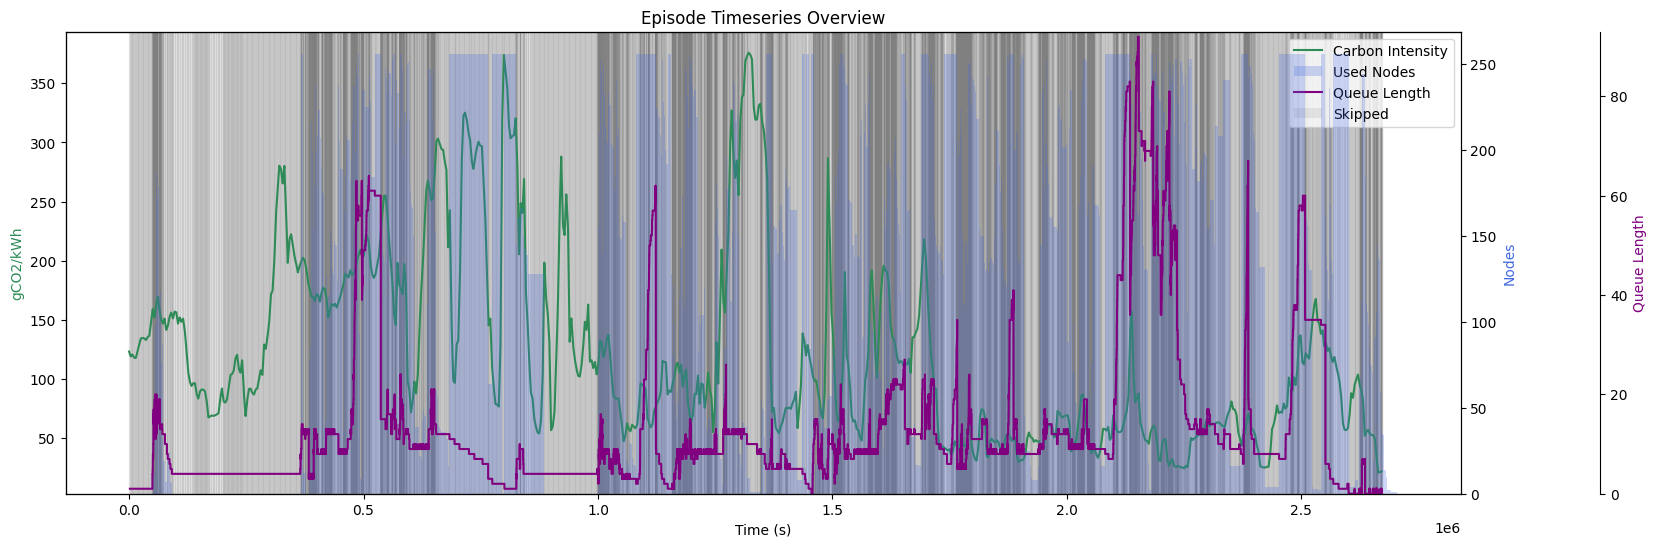

In [5]:
val.render_timeseries_plot(raw_stats['seed_1_6000000_steps']['action_traces'])